In [16]:
print('MOHAN S')
print('212223240094')

MOHAN S
212223240094


In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision import models, datasets
from torchvision.models import VGG19_Weights

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("All libraries imported successfully! ✅")

All libraries imported successfully! ✅


In [4]:
from google.colab import files

uploaded = files.upload()

print("Upload completed! ✅")


Saving chip_data.zip to chip_data.zip
Upload completed! ✅


In [5]:
import os
import zipfile

# Unzip the dataset
with zipfile.ZipFile("chip_data.zip", "r") as zip_ref:
    zip_ref.extractall("data")

print("Dataset extracted successfully! ✅")

# Check the folder structure
print("\nFiles and folders inside data:")
for root, dirs, files in os.walk("data"):
    level = root.replace("data", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for file in files[:5]:
        print(f"{indent}  {file}")

Dataset extracted successfully! ✅

Files and folders inside data:
data/
  dataset/
    test/
      defect/
        D0_C148.jpg
        D1_C139.jpg
        D1_C517.jpg
        D2_C221.jpg
        D1_C223.jpg
        .ipynb_checkpoints/
          D0_C126-checkpoint.jpg
          D0_C153-checkpoint.jpg
      notdefect/
        D1_C511.jpg
        D0_C524.jpg
        D2_C144.jpg
        D1_C206.jpg
        D1_C39.jpg
    train/
      defect/
        D0_C214.jpg
        D0_C9.jpg
        D0_C164.jpg
        D2_C514.jpg
        D2_C204.jpg
      notdefect/
        D1_C511.jpg
        D0_C524.jpg
        D0_C50.jpg
        D0_C1215.jpg
        D0_C148.jpg


In [6]:
import os
import shutil

# Remove unwanted Jupyter checkpoint folders
for root, dirs, files in os.walk("data"):
    for directory in dirs:
        if directory == ".ipynb_checkpoints":
            shutil.rmtree(os.path.join(root, directory))

print("Unwanted checkpoint folders removed! ✅")

# Check train and test folders
train_path = "data/dataset/train"
test_path = "data/dataset/test"

print("\nTrain classes:")
print(os.listdir(train_path))

print("\nTest classes:")
print(os.listdir(test_path))

# Count images in each class
for folder in [train_path, test_path]:
    print(f"\n{folder}")

    for class_name in sorted(os.listdir(folder)):
        class_path = os.path.join(folder, class_name)

        if os.path.isdir(class_path):
            count = len([
                f for f in os.listdir(class_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ])
            print(f"{class_name}: {count} images")

Unwanted checkpoint folders removed! ✅

Train classes:
['defect', 'notdefect']

Test classes:
['defect', 'notdefect']

data/dataset/train
defect: 52 images
notdefect: 120 images

data/dataset/test
defect: 31 images
notdefect: 88 images


In [7]:
# Image transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Dataset paths
dataset_path = "data/dataset"

# Load training and testing datasets
train_dataset = datasets.ImageFolder(
    root=f"{dataset_path}/train",
    transform=transform
)

test_dataset = datasets.ImageFolder(
    root=f"{dataset_path}/test",
    transform=transform
)

# Display class information
print("Classes:", train_dataset.classes)
print("Class to index:", train_dataset.class_to_idx)

print("\nTotal training images:", len(train_dataset))
print("Total testing images:", len(test_dataset))

# Check first image
first_image, label = train_dataset[0]

print("\nFirst image shape:", first_image.shape)
print("First image label:", label)
print("First image class:", train_dataset.classes[label])

Classes: ['defect', 'notdefect']
Class to index: {'defect': 0, 'notdefect': 1}

Total training images: 172
Total testing images: 119

First image shape: torch.Size([3, 224, 224])
First image label: 0
First image class: defect


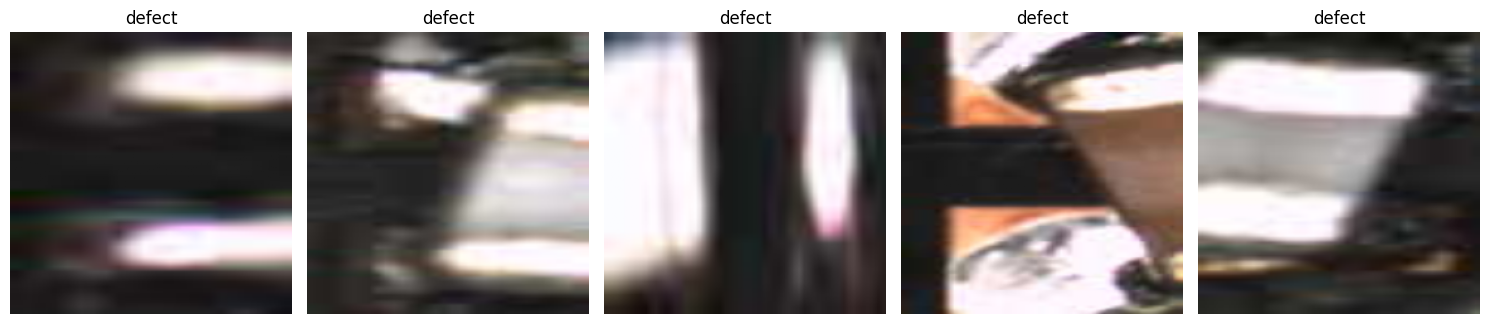

In [8]:
# Display sample images

def show_sample_images(dataset, num_images=5):
    fig, axes = plt.subplots(1, num_images, figsize=(15, 4))

    for i in range(num_images):
        image, label = dataset[i]

        # Convert (C, H, W) → (H, W, C)
        image = image.permute(1, 2, 0)

        axes[i].imshow(image)
        axes[i].set_title(dataset.classes[label])
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()


# Show 5 training images
show_sample_images(train_dataset, num_images=5)

In [9]:
# Create DataLoaders

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

# Check one batch
images, labels = next(iter(train_loader))

print("\nBatch image shape:", images.shape)
print("Batch labels shape:", labels.shape)
print("Labels:", labels)

Train batches: 6
Test batches: 4

Batch image shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])
Labels: tensor([0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 0, 1])


In [10]:
# Select GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

# Load pretrained VGG19
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

# Move model to GPU
model = model.to(device)

print("VGG19 loaded successfully! ✅")

Using device: cuda
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:06<00:00, 88.6MB/s]


VGG19 loaded successfully! ✅


In [11]:
# Check the original final layer
print("Original final layer:")
print(model.classifier[-1])

# Replace the final layer
model.classifier[-1] = nn.Linear(
    model.classifier[-1].in_features,
    1
)

# Freeze VGG19 feature extraction layers
for param in model.features.parameters():
    param.requires_grad = False

# Move model to GPU
model = model.to(device)

print("\nNew final layer:")
print(model.classifier[-1])

print("\nVGG19 modified successfully! ✅")

Original final layer:
Linear(in_features=4096, out_features=1000, bias=True)

New final layer:
Linear(in_features=4096, out_features=1, bias=True)

VGG19 modified successfully! ✅


In [12]:
# Define loss function
criterion = nn.BCEWithLogitsLoss()

# Optimizer
# Only train the final classifier layer
optimizer = optim.Adam(
    model.classifier[-1].parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)
print("\nLoss function and optimizer configured successfully! ✅")

Loss function: BCEWithLogitsLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)

Loss function and optimizer configured successfully! ✅


Epoch [1/10] Train Loss: 0.6449 | Validation Loss: 0.4595
Epoch [2/10] Train Loss: 0.4925 | Validation Loss: 0.3908
Epoch [3/10] Train Loss: 0.3949 | Validation Loss: 0.3707
Epoch [4/10] Train Loss: 0.3466 | Validation Loss: 0.3159
Epoch [5/10] Train Loss: 0.2999 | Validation Loss: 0.2842
Epoch [6/10] Train Loss: 0.2651 | Validation Loss: 0.2669
Epoch [7/10] Train Loss: 0.2697 | Validation Loss: 0.2540
Epoch [8/10] Train Loss: 0.2381 | Validation Loss: 0.2482
Epoch [9/10] Train Loss: 0.2358 | Validation Loss: 0.2386
Epoch [10/10] Train Loss: 0.2124 | Validation Loss: 0.2317


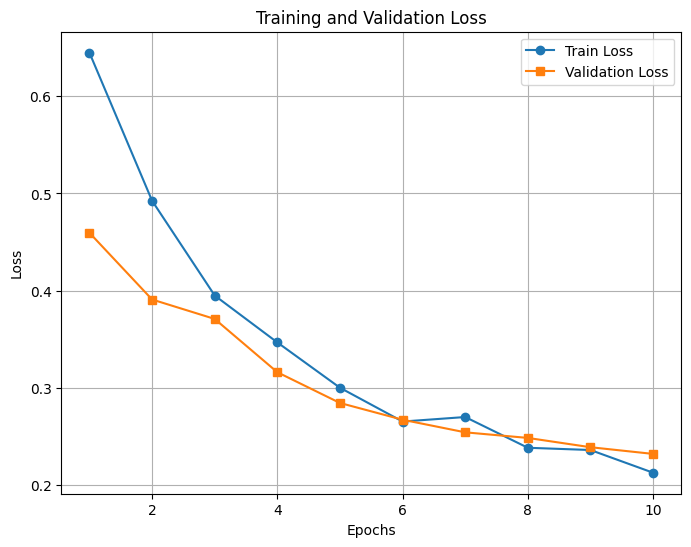

In [13]:
def train_model(model, train_loader, test_loader, num_epochs=10):

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):

        # -------------------------
        # Training
        # -------------------------
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        # -------------------------
        # Validation / Testing
        # -------------------------
        model.eval()
        val_loss = 0.0

        with torch.no_grad():

            for images, labels in test_loader:

                images = images.to(device)
                labels = labels.float().unsqueeze(1).to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_loss += loss.item()

        val_loss = val_loss / len(test_loader)
        val_losses.append(val_loss)

        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Train Loss: {train_loss:.4f} | "
            f"Validation Loss: {val_loss:.4f}"
        )

    # -------------------------
    # Plot Loss
    # -------------------------
    plt.figure(figsize=(8, 6))

    plt.plot(
        range(1, num_epochs + 1),
        train_losses,
        label="Train Loss",
        marker="o"
    )

    plt.plot(
        range(1, num_epochs + 1),
        val_losses,
        label="Validation Loss",
        marker="s"
    )

    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")

    plt.legend()
    plt.grid()
    plt.show()


# Start training
train_model(
    model,
    train_loader,
    test_loader,
    num_epochs=10
)

Test Accuracy: 0.9160
Test Accuracy: 91.60%

Confusion Matrix:
[[23  8]
 [ 2 86]]


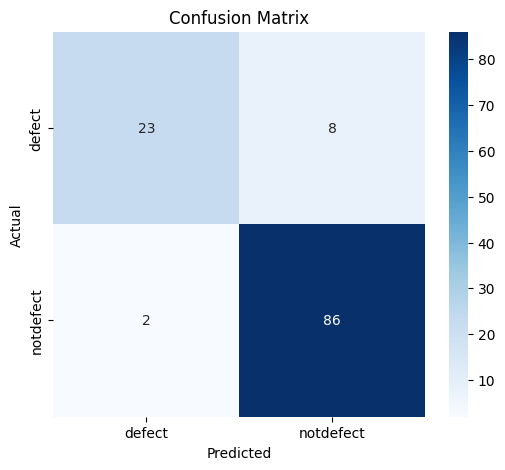


Classification Report:
              precision    recall  f1-score   support

      defect       0.92      0.74      0.82        31
   notdefect       0.91      0.98      0.95        88

    accuracy                           0.92       119
   macro avg       0.92      0.86      0.88       119
weighted avg       0.92      0.92      0.91       119



In [14]:
def test_model(model, test_loader):

    model.eval()

    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            # Model prediction
            outputs = model(images)

            # Convert logits to probabilities
            probs = torch.sigmoid(outputs)

            # Threshold = 0.5
            predicted = (probs > 0.5).long().squeeze(1)

            # Accuracy
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Store predictions and actual labels
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate accuracy
    accuracy = correct / total

    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test Accuracy: {accuracy * 100:.2f}%")

    # -------------------------
    # Confusion Matrix
    # -------------------------

    cm = confusion_matrix(all_labels, all_preds)

    print("\nConfusion Matrix:")
    print(cm)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=train_dataset.classes,
        yticklabels=train_dataset.classes
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")

    plt.show()

    # -------------------------
    # Classification Report
    # -------------------------

    print("\nClassification Report:")

    print(
        classification_report(
            all_labels,
            all_preds,
            target_names=train_dataset.classes
        )
    )


# Evaluate the model
test_model(model, test_loader)

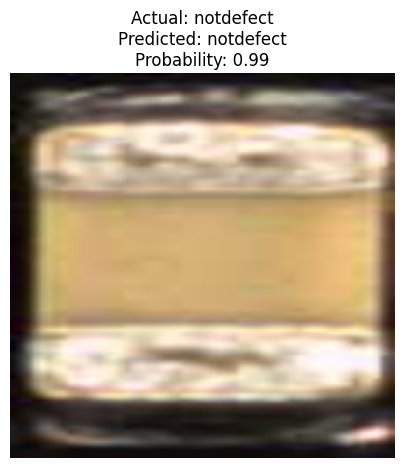

Actual: notdefect
Predicted: notdefect
Probability: 0.99


In [15]:
def predict_image(model, image_index, dataset):

    model.eval()

    # Get image and actual label
    image, label = dataset[image_index]

    with torch.no_grad():

        # Add batch dimension
        image_tensor = image.unsqueeze(0).to(device)

        # Model output
        output = model(image_tensor)

        # Convert output to probability
        probability = torch.sigmoid(output).item()

        # Convert probability to class
        predicted = 1 if probability > 0.5 else 0

    # Class names
    class_names = dataset.classes

    # Display image
    image_to_display = transforms.ToPILImage()(image)

    plt.figure(figsize=(5, 5))
    plt.imshow(image_to_display)

    plt.title(
        f"Actual: {class_names[label]}\n"
        f"Predicted: {class_names[predicted]}\n"
        f"Probability: {probability:.2f}"
    )

    plt.axis("off")
    plt.show()

    print("Actual:", class_names[label])
    print("Predicted:", class_names[predicted])
    print(f"Probability: {probability:.2f}")


# Test a single image
predict_image(
    model,
    image_index=55,
    dataset=test_dataset
)